# Surface Elevation Change

* Description: The change in surface elevation of the Antarctic grounded ice sheet is measured from all available ESA Radar Altimetry missions (ERS-1, ERS-2, ENVISAT, CryoSat-2, Sentinel-3A, and Sentinel-3B) from 1991 to 2021. 
* Original Data Source: https://www.cpom.ucl.ac.uk/csopr/icesheets2/index.php
* Reference: https://doi.org/10.1029/2019GL082182, https://climate.esa.int/en/projects/ice-sheets-antarctic/
* OSC entry: https://opensciencedata.esa.int/products/sec-antarctic-ice-sheet/collection
* License: cc-by-4.0
* Repo Folder: ./datasets/sec

In [12]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore", message="Polyfit may be poorly conditioned")
warnings.filterwarnings("ignore", message="invalid value encountered in cast", category=RuntimeWarning)

In [13]:
url = 'https://s3.waw4-1.cloudferro.com/EarthCODE/OSCAssets/polar_cube_datasets/surface_elevation/ESACCI-AIS-L3C-SEC-MULTIMISSION-5KM-5YEAR-MEANS-1991-2021-fv1.zarr/'

In [14]:
ds = xr.open_zarr(url)
ds

<xarray.Dataset> Size: 616MB
Dimensions:            (y: 968, x: 1128, time: 27, bounds: 2)
Coordinates:
  * y                  (y) float32 4kB -2.418e+06 -2.412e+06 ... 2.418e+06
  * x                  (x) float32 5kB -2.818e+06 -2.812e+06 ... 2.818e+06
    lat                (y, x) float64 9MB dask.array<chunksize=(968, 1128), meta=np.ndarray>
    lon                (y, x) float64 9MB dask.array<chunksize=(968, 1128), meta=np.ndarray>
  * time               (time) datetime64[ns] 216B 1993-12-01 ... 2020-01-01
Dimensions without coordinates: bounds
Data variables:
    basin_id           (y, x) float32 4MB dask.array<chunksize=(968, 1128), meta=np.ndarray>
    cell_end_times     (time, y, x) float32 118MB dask.array<chunksize=(27, 968, 1128), meta=np.ndarray>
    cell_start_times   (time, y, x) float32 118MB dask.array<chunksize=(27, 968, 1128), meta=np.ndarray>
    cell_time_lengths  (time, y, x) float32 118MB dask.array<chunksize=(27, 968, 1128), meta=np.ndarray>
    grid_projection    int64 8B ...
    sec                (time, y, x) float32 118MB dask.array<chunksize=(27, 968, 1128), meta=np.ndarray>
    sec_uncertainty    (time, y, x) float32 118MB dask.array<chunksize=(27, 968, 1128), meta=np.ndarray>
    surface_type       (y, x) float32 4MB dask.array<chunksize=(968, 1128), meta=np.ndarray>
    time_bounds        (time, bounds) datetime64[ns] 432B dask.array<chunksize=(27, 2), meta=np.ndarray>
Attributes: (12/40)
    title:                  5yr Antarctic Surface Elevation Change at 5.0km r...
    institution:            University College London (UCL)
    creator_email:          cpom@leeds.ac.uk
    creator_name:           University College London (UCL), Centre for Polar...
    creator_url:            www.cpom.ucl.ac.uk/csopr
    comment:                This data was prepared by UCL as a part of the ES...
    ...                     ...
    spatial_resolution:     5km grid
    dhdt_sw_version:        0ded87aa6
    product_sw_version:     0ded87aa6
    product_created:        2021-06-03T11:07:35Z
    license:                ESA CCI Data Policy: free and open access
    netCDF_version:         NETCDF4

In [15]:
# compute surface evelavtion change trend
sec = ds.sec.where(ds.surface_type == 2)
unc = ds.sec_uncertainty.where(ds.surface_type == 2)

t = (ds.time.dt.year + (ds.time.dt.dayofyear - 1) / 365.25)
t = t - t.mean()

sec_y = sec.assign_coords(year=("time", ds.time.dt.year.values))
trend = sec_y.swap_dims({"time": "year"}).polyfit("year", 1).polyfit_coefficients.sel(degree=1)
trend = trend * 1000   # mm yr-2, change in SEC rate per year

In [16]:
mean_sec = sec.mean("time") * 1000
mean_unc = unc.mean("time") * 1000
signal_to_noise = abs(mean_sec) / mean_unc

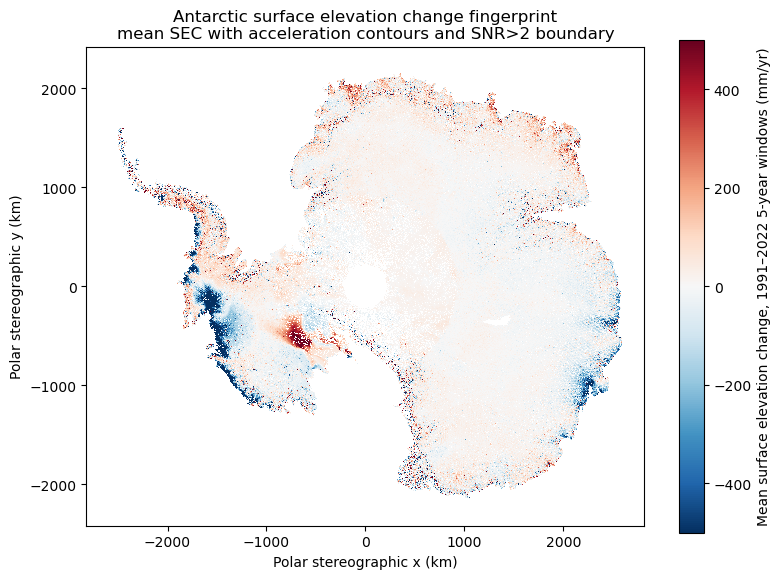

In [17]:
fig, ax = plt.subplots(figsize=(9, 8))

im = ax.pcolormesh(
    ds.x / 1000, ds.y / 1000, mean_sec,
    shading="auto", cmap="RdBu_r", vmin=-500, vmax=500
)

ax.set_aspect("equal")
ax.set_title("Antarctic surface elevation change fingerprint\nmean SEC with acceleration contours and SNR>2 boundary")
ax.set_xlabel("Polar stereographic x (km)")
ax.set_ylabel("Polar stereographic y (km)")

cb = plt.colorbar(im, ax=ax, shrink=0.8)
cb.set_label("Mean surface elevation change, 1991–2022 5-year windows (mm/yr)")

plt.show()

### Group by IBIE basin ID

In [18]:
ds.basin_id

<xarray.DataArray 'basin_id' (y: 968, x: 1128)> Size: 4MB
dask.array<open_dataset-basin_id, shape=(968, 1128), dtype=float32, chunksize=(968, 1128), chunktype=numpy.ndarray>
Coordinates:
  * y        (y) float32 4kB -2.418e+06 -2.412e+06 ... 2.412e+06 2.418e+06
  * x        (x) float32 5kB -2.818e+06 -2.812e+06 ... 2.812e+06 2.818e+06
    lat      (y, x) float64 9MB dask.array<chunksize=(968, 1128), meta=np.ndarray>
    lon      (y, x) float64 9MB dask.array<chunksize=(968, 1128), meta=np.ndarray>
Attributes:
    long_name:     Glacialogical basin identification number
    comment:       IMBIE glacialogical basin id number (Zwally et al., 2012) ...
    source:        IMBIE http://imbie.org/imbie-2016/drainage-basins/
    grid_mapping:  grid_projection

In [19]:
basin = ds.basin_id.where(ds.surface_type == 2).load()

basin_summary = xr.Dataset({
    "mean_sec_mm_yr": mean_sec.groupby(basin).mean(),
    "trend_mm_yr2": trend.groupby(basin).mean(),
    "mean_unc_mm_yr": mean_unc.groupby(basin).mean(),
    "snr": signal_to_noise.groupby(basin).mean()
})

group_dim = list(basin_summary.dims)[0]

df = (
    basin_summary
    .rename({group_dim: "basin_id"})
    .sel(basin_id=np.arange(1, 28))
    .to_dataframe()
    .reset_index()
)

df

,basin_id,mean_sec_mm_yr,degree,trend_mm_yr2,mean_unc_mm_yr,snr
0,1.0,44.015919,1,5.475258,233.956375,0.546577
1,2.0,9.206942,1,4.643902,93.265823,0.468455
2,3.0,12.607417,1,0.826894,59.343853,0.526312
3,4.0,20.372700,1,-0.226356,203.664749,0.412536
4,5.0,47.088249,1,0.044380,219.665802,0.477566
5,6.0,25.405363,1,0.023379,179.830673,0.399779
6,7.0,39.770779,1,4.902592,159.618057,0.468430
7,8.0,46.640488,1,4.055493,242.148438,0.399865
8,9.0,5.079136,1,-0.410436,221.124496,0.324116
9,10.0,-4.877558,1,0.294238,69.487480,0.339629


In [20]:
# create a geopandas frame for the basins
import xarray as xr
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from affine import Affine
from rasterio.features import shapes
from shapely.geometry import shape
from pyproj import CRS

In [21]:
# generate polygons from the raster based on basin id
crs = CRS.from_wkt(ds.grid_projection.attrs["crs_wkt"])

basin = ds.basin_id.where(ds.surface_type == 2).load().astype("int16")
basin_arr = basin.values

x = ds.x.values
y = ds.y.values
dx = float(np.abs(x[1] - x[0]))
dy = float(np.abs(y[1] - y[0]))

transform = Affine.translation(x[0] - dx / 2, y[0] - dy / 2) * Affine.scale(dx, dy)

records = [
    {"basin_id": int(v), "geometry": shape(g)}
    for g, v in shapes(basin_arr, mask=(basin_arr > 0), transform=transform)
    if int(v) > 0
]

basin_gdf = gpd.GeoDataFrame(records, crs=crs).dissolve(by="basin_id").reset_index()
basin_gdf["basin_id"] = basin_gdf["basin_id"].astype(int)
df["basin_id"] = df["basin_id"].astype(int)

basin_map = basin_gdf.merge(df, on="basin_id", how="left")
basin_map.head()

,basin_id,geometry,mean_sec_mm_yr,degree,trend_mm_yr2,mean_unc_mm_yr,snr
0,1,"MULTIPOLYGON (((-1175000 300000, -1185000 3000...",44.015919,1,5.475258,233.956375,0.546577
1,2,"MULTIPOLYGON (((-50000 -185000, -55000 -185000...",9.206942,1,4.643902,93.265823,0.468455
2,3,"MULTIPOLYGON (((805000 255000, 795000 255000, ...",12.607417,1,0.826894,59.343853,0.526312
3,4,"MULTIPOLYGON (((-765000 1085000, -760000 10850...",20.372700,1,-0.226356,203.664749,0.412536
4,5,"MULTIPOLYGON (((-360000 2045000, -365000 20450...",47.088249,1,0.044380,219.665802,0.477566


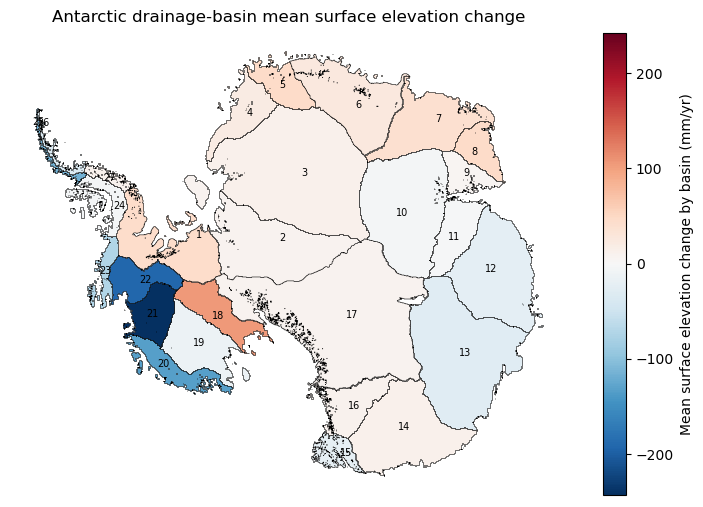

In [22]:
from matplotlib.colors import TwoSlopeNorm


v = basin_map["mean_sec_mm_yr"]
lim = np.nanmax(np.abs(v))

norm = TwoSlopeNorm(vmin=-lim, vcenter=0, vmax=lim)

fig, ax = plt.subplots(figsize=(9, 8))

basin_map.plot(
    column="mean_sec_mm_yr",
    ax=ax,
    cmap="RdBu_r",
    norm=norm,
    legend=True,
    legend_kwds={
        "label": "Mean surface elevation change by basin (mm/yr)",
        "shrink": 0.75
    },
    edgecolor="black",
    linewidth=0.4,
    missing_kwds={"color": "lightgrey", "label": "No data"}
)

for _, r in basin_map.iterrows():
    p = r.geometry.representative_point()
    ax.text(p.x, p.y, int(r.basin_id), ha="center", va="center", fontsize=7)


ax.set_aspect("equal")
ax.set_axis_off()
ax.set_title("Antarctic drainage-basin mean surface elevation change")

plt.show()